# Tutorial Debug — Per-Move Reward Logging

Runs every tutorial scenario **once** with the **tutorial-trained** Kitchen Sink agent and
logs every move alongside its reward. Use this to spot reward bugs, incorrect move
types, or unexpected reward magnitudes.

**Checkpoint:** `outputs/phase2/kitchen_sink/checkpoints/tutorial_complete.pt`

**Key difference from `kitchen_sink_tutorial.ipynb`:** That notebook only tracks
aggregate pass rates. This notebook captures the full per-move reward breakdown
by stepping the environment directly and zipping `info["executed"]` with
`info["transitions"]`.

In [1]:
import sys, os, time, random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import fields
from collections import defaultdict

# Ensure project root is on path
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))
elif os.path.isdir(os.path.join(_cwd, "simulation")):
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

Project root: /home/franko/CT-DRL-MA
PyTorch: 2.10.0+cu128
CUDA: True


In [2]:
import torch.nn as nn
from torch.nn.utils import remove_spectral_norm

from simulation.rl.agent_registry import create_agent
from simulation.training.unified_curriculum_trainer import (
    create_env_factory, build_agent_config,
)
from simulation.training.tutorial_scenarios import (
    ALL_SCENARIOS, TUTORIAL_TIME, TutorialScenario,
)
from simulation.training.unified_tutorial_runner import (
    TUTORIAL_REWARD_SUCCESS, TUTORIAL_REWARD_TIMEOUT,
)
from simulation.config.operations_config import RewardWeights
from simulation.rl.variants.networks.noisy_linear import NoisyLinear

# ---- Environment & Agent ----
env_factory = create_env_factory(rows=5, bays=58, tiers=5, tracks=7, split_factor=20)
base_cfg = build_agent_config(rows=5, bays=58, tiers=5, split_factor=20, tracks=7)
agent = create_agent("kitchen_sink", base_cfg)

# ---- Load tutorial-trained checkpoint ----
CHECKPOINT = os.path.join(PROJECT_ROOT, "outputs", "phase2", "kitchen_sink",
                          "checkpoints", "tutorial_complete.pt")
ckpt = torch.load(CHECKPOINT, map_location=base_cfg.device, weights_only=False)

# Strip spectral norm (checkpoint saved without it, agent adds it)
for net in (agent.q_net, agent.target_net):
    for _, module in list(net.named_modules()):
        if isinstance(module, nn.Conv3d):
            try:
                remove_spectral_norm(module)
            except ValueError:
                pass

agent.q_net.load_state_dict(ckpt["q_net"], strict=False)
agent.target_net.load_state_dict(ckpt["target_net"], strict=False)
agent.optimizer.load_state_dict(ckpt["optimizer"])
agent.step_count = ckpt["step_count"]
print(f"Loaded checkpoint: {CHECKPOINT}")
print(f"  step_count = {agent.step_count}")

# Zero out NoisyNet noise for deterministic greedy policy
for m in agent.q_net.modules():
    if isinstance(m, NoisyLinear):
        m.weight_epsilon.zero_()
        m.bias_epsilon.zero_()
agent._pre_act_hook = lambda: None
agent._post_optimize_hook = lambda: None
print("  NoisyNet noise zeroed + hooks disabled — deterministic greedy policy")

env = env_factory()

n_params = sum(p.numel() for p in agent.q_net.parameters())
print(f"\nKitchen Sink agent: {n_params:,} params")
print(f"Scenarios: {len(ALL_SCENARIOS)}")
print()

# ---- Reward weights reference ----
w = RewardWeights()
print("Reward Weights:")
print("-" * 45)
for f in fields(w):
    print(f"  {f.name:40s} {getattr(w, f.name):>8}")
print(f"\n  TUTORIAL_REWARD_SUCCESS  = {TUTORIAL_REWARD_SUCCESS}")
print(f"  TUTORIAL_REWARD_TIMEOUT  = {TUTORIAL_REWARD_TIMEOUT}")

Loaded checkpoint: /home/franko/CT-DRL-MA/outputs/phase2/kitchen_sink/checkpoints/tutorial_complete.pt
  step_count = 77508
  NoisyNet noise zeroed + hooks disabled — deterministic greedy policy

Kitchen Sink agent: 177,956 params
Scenarios: 25

Reward Weights:
---------------------------------------------
  per_meter_cost                             -0.001
  per_second_cost                           -0.0005
  reward_yard_to_train                          5.0
  reward_yard_to_truck                          3.0
  reward_train_to_yard                          1.0
  reward_truck_to_yard                          0.8
  reward_train_to_truck                         4.0
  reward_truck_to_train                         4.0
  reward_terminal_truck                         2.0
  penalty_yard_to_yard                         -0.2
  reward_train_departed                        10.0
  penalty_train_leftover_per_id                -3.0
  endday_blocking_weight                       -0.5
  endday_leftove

/home/franko/.cache/pypoetry/virtualenvs/ct-drl-ma-7RJlkqYG-py3.12/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KernelDensity from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# ================================================================
# run_scenario_with_logging()
#
# Mirrors UnifiedTutorialRunner.run_scenario() but captures the
# per-move reward by zipping executed entries with transitions.
# ================================================================

from simulation.env.env import CraneState
from simulation.config.crane_config import CraneDefaults
from simulation.training.unified_tutorial_runner import (
    _clear_yard, _clear_parking, _clear_rail, _StubDayPlan,
)


def _reset_tutorial(env):
    """Clear env state for a tutorial scenario (copied from runner)."""
    env.current_time = TUTORIAL_TIME
    env.day_index = 0
    env.day_plan = _StubDayPlan(TUTORIAL_TIME)
    env._scheduled_trains = []

    env.trains.clear()
    env.trucks.clear()
    env.terminal_trucks.clear()
    env._tt_busy_until.clear()
    env._admitted_truck_ids.clear()
    env._departed_cache.clear()
    env.reward_engine.reset_train_tracking()

    _clear_yard(env.yard)
    _clear_parking(env.parking)
    _clear_rail(env.rail)

    env.cranes = [CraneState(i, None) for i in range(env.num_cranes)]
    env.crane_zones = env._make_crane_zones(
        overlap_bays=CraneDefaults.ZONE_OVERLAP_BAYS,
    )
    env.rmgc.set_layout(yard=env.yard, rail=env.rail, num_tracks=env.num_tracks)
    env._train_heat_bays = set()


def run_scenario_with_logging(env, agent, scenario):
    """Run one scenario, return dict with metadata + per-move log."""
    _reset_tutorial(env)
    scenario.setup(env)
    env._update_train_heat()
    env.rmgc.set_layout(yard=env.yard, rail=env.rail, num_tracks=env.num_tracks)

    moves = []          # per-move dicts
    step_events = []    # per-step non-move rewards
    total_reward = 0.0
    agent_moves = 0

    for step_idx in range(scenario.max_steps):
        state, reward, done, info = env.step_all_cranes(agent)
        total_reward += reward

        executed = info.get("executed", [])
        transitions = info.get("transitions", [])
        crane_results = info.get("crane_results", [])

        # Sum of individual move rewards from transitions
        move_reward_sum = sum(t.reward for t in transitions)
        # Non-move reward = step total - sum of move rewards
        non_move_reward = reward - move_reward_sum

        if abs(non_move_reward) > 1e-6:
            step_events.append({
                "step": step_idx,
                "type": "non_move",
                "reward": round(non_move_reward, 6),
                "detail": "departure/waiting/idle",
            })

        # Zip executed entries with transitions (1:1 correspondence)
        # Each crane produces at most 1 transition + 1 executed entry
        for i, ex in enumerate(executed):
            agent_moves += 1
            t_reward = transitions[i].reward if i < len(transitions) else None

            move_dict = {
                "step": step_idx,
                "move_num": agent_moves,
                "move_type": ex.get("move_type", "?"),
                "container_id": ex.get("container_id", ex.get("truck_id", "")),
                "distance_m": ex.get("distance_m", 0.0),
                "time_s": ex.get("time_s", 0.0),
                "reward": round(t_reward, 6) if t_reward is not None else None,
                "proximity_bonus": ex.get("proximity_bonus"),
            }
            moves.append(move_dict)

        # Check success
        if scenario.check_success(env):
            total_reward += TUTORIAL_REWARD_SUCCESS
            step_events.append({
                "step": step_idx, "type": "SUCCESS_BONUS",
                "reward": TUTORIAL_REWARD_SUCCESS, "detail": "scenario passed",
            })
            passed = scenario.check_pass(env, agent_moves)
            return {
                "scenario_id": scenario.id,
                "name": scenario.name,
                "passed": passed,
                "steps": step_idx + 1,
                "agent_moves": agent_moves,
                "total_reward": round(total_reward, 4),
                "moves": moves,
                "step_events": step_events,
            }

        if done:
            break

    # Timeout
    total_reward += TUTORIAL_REWARD_TIMEOUT
    step_events.append({
        "step": scenario.max_steps - 1, "type": "TIMEOUT_PENALTY",
        "reward": TUTORIAL_REWARD_TIMEOUT, "detail": "scenario timed out",
    })
    return {
        "scenario_id": scenario.id,
        "name": scenario.name,
        "passed": False,
        "steps": scenario.max_steps,
        "agent_moves": agent_moves,
        "total_reward": round(total_reward, 4),
        "moves": moves,
        "step_events": step_events,
    }


print("run_scenario_with_logging() defined")

run_scenario_with_logging() defined


In [4]:
# ================================================================
# Run all 25 scenarios
# ================================================================

all_logs = {}
t0 = time.time()

for scenario in ALL_SCENARIOS:
    result = run_scenario_with_logging(env, agent, scenario)
    all_logs[scenario.id] = result
    status = "PASS" if result["passed"] else "FAIL"
    print(f"  S{result['scenario_id']:>2d} [{status}] "
          f"{result['name']:40s} "
          f"moves={result['agent_moves']:>2d}  "
          f"steps={result['steps']:>3d}  "
          f"reward={result['total_reward']:>+8.2f}")

elapsed = time.time() - t0
print(f"\nAll {len(ALL_SCENARIOS)} scenarios complete in {elapsed:.1f}s")

  S 1 [PASS] park_truck                               moves= 2  steps=  1  reward=   +8.50
  S 2 [PASS] train_import                             moves= 1  steps=  1  reward=   +5.81
  S 3 [PASS] yard_to_truck                            moves= 1  steps=  1  reward=   +7.90
  S 4 [PASS] yard_to_train                            moves= 1  steps=  1  reward=   +9.86
  S 5 [PASS] import_and_export                        moves= 2  steps=  1  reward=  +10.68
  S 6 [PASS] park_then_import                         moves= 2  steps=  1  reward=   +5.80
  S 7 [PASS] full_chain_truck                         moves= 3  steps=  2  reward=   +9.37
  S 8 [PASS] delivery_to_train                        moves= 3  steps=  2  reward=   +9.88
  S 9 [FAIL] unbury_for_truck                         moves=49  steps= 25  reward=  -40.48
  S10 [PASS] unbury_for_train                         moves= 2  steps=  1  reward=   +9.56
  S11 [FAIL] random_import_chain                      moves=40  steps= 40  reward= -456.70

In [5]:
# ================================================================
# Summary table
# ================================================================

rows = []
for sid in sorted(all_logs.keys()):
    r = all_logs[sid]
    move_types = defaultdict(int)
    for m in r["moves"]:
        move_types[m["move_type"]] += 1
    types_str = ", ".join(f"{k}={v}" for k, v in sorted(move_types.items()))
    rows.append({
        "ID": f"S{sid}",
        "Name": r["name"],
        "Pass": "Y" if r["passed"] else "N",
        "Steps": r["steps"],
        "Moves": r["agent_moves"],
        "Total R": r["total_reward"],
        "Move Types": types_str,
    })

df_summary = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80)
df_summary

,ID,Name,Pass,Steps,Moves,Total R,Move Types
0,S1,park_truck,Y,1,2,8.5011,"PARK_TRUCK=1, YARD_TO_TRUCK=1"
1,S2,train_import,Y,1,1,5.8120,TRAIN_TO_YARD=1
2,S3,yard_to_truck,Y,1,1,7.9011,YARD_TO_TRUCK=1
3,S4,yard_to_train,Y,1,1,9.8639,YARD_TO_TRAIN=1
4,S5,import_and_export,Y,1,2,10.6760,"TRAIN_TO_YARD=1, YARD_TO_TRAIN=1"
5,S6,park_then_import,Y,1,2,5.7971,"PARK_TRUCK=1, TRUCK_TO_YARD=1"
6,S7,full_chain_truck,Y,2,3,9.3666,"PARK_TRUCK=1, TRAIN_TO_YARD=1, YARD_TO_TRUCK=1"
7,S8,delivery_to_train,Y,2,3,9.8801,"PARK_TRUCK=1, TRUCK_TO_YARD=1, YARD_TO_TRAIN=1"
8,S9,unbury_for_truck,N,25,49,-40.4797,YARD_TO_YARD=49
9,S10,unbury_for_train,Y,1,2,9.5584,"YARD_TO_TRAIN=1, YARD_TO_YARD=1"


In [6]:
# ================================================================
# Per-scenario move detail tables
# ================================================================

for sid in sorted(all_logs.keys()):
    r = all_logs[sid]
    print(f"\n{'='*80}")
    status = "PASS" if r["passed"] else "FAIL"
    print(f"S{sid}: {r['name']}  [{status}]  "
          f"total_reward={r['total_reward']:+.4f}  "
          f"steps={r['steps']}  moves={r['agent_moves']}")
    print(f"{'='*80}")

    if not r["moves"] and not r["step_events"]:
        print("  (no moves or events)")
        continue

    # Merge moves and step_events into a timeline
    timeline = []
    for m in r["moves"]:
        timeline.append((m["step"], "move", m))
    for e in r["step_events"]:
        timeline.append((e["step"], "event", e))
    timeline.sort(key=lambda x: (x[0], 0 if x[1] == "event" else 1))

    print(f"  {'#':>3s}  {'Step':>4s}  {'Type':>6s}  {'Move Type':<28s}  "
          f"{'Container/Truck':<14s}  {'Dist(m)':>8s}  {'Time(s)':>8s}  "
          f"{'Reward':>9s}  Notes")
    print(f"  {'-'*3}  {'-'*4}  {'-'*6}  {'-'*28}  "
          f"{'-'*14}  {'-'*8}  {'-'*8}  {'-'*9}  {'-'*20}")

    for step_val, kind, data in timeline:
        if kind == "move":
            reward = data["reward"]
            # Flag suspicious rewards
            flags = []
            mt = data["move_type"]
            if reward is not None:
                # Productive moves should be positive
                productive = ["TRAIN_TO_YARD", "TRUCK_TO_YARD", "YARD_TO_TRAIN",
                              "YARD_TO_TRUCK", "TRAIN_TO_TRUCK", "TRUCK_TO_TRAIN",
                              "YARD_TO_TERMINAL_TRUCK"]
                if mt in productive and reward < 0:
                    flags.append("NEGATIVE_PRODUCTIVE")
                if mt == "YARD_TO_YARD" and reward > 0:
                    flags.append("POSITIVE_RESTACK")
                if abs(reward) > 15:
                    flags.append("LARGE_REWARD")

            prox = data.get("proximity_bonus")
            if prox is not None and prox > 0:
                flags.append(f"prox={prox:.2f}")

            flag_str = "  ".join(flags) if flags else ""
            reward_str = f"{reward:>+9.4f}" if reward is not None else "     None"

            print(f"  {data['move_num']:>3d}  {step_val:>4d}  {'move':>6s}  "
                  f"{mt:<28s}  {data['container_id']:<14s}  "
                  f"{data['distance_m']:>8.2f}  {data['time_s']:>8.2f}  "
                  f"{reward_str}  {flag_str}")
        else:
            # Step event (non-move reward)
            print(f"  {'':>3s}  {step_val:>4d}  {'event':>6s}  "
                  f"{data['type']:<28s}  {'':14s}  {'':>8s}  {'':>8s}  "
                  f"{data['reward']:>+9.4f}  {data['detail']}")

    # Reward accounting
    move_r = sum(m["reward"] for m in r["moves"] if m["reward"] is not None)
    event_r = sum(e["reward"] for e in r["step_events"])
    print(f"\n  Reward breakdown: moves={move_r:+.4f}  events={event_r:+.4f}  "
          f"total={r['total_reward']:+.4f}")
    residual = r["total_reward"] - move_r - event_r
    if abs(residual) > 0.01:
        print(f"  *** RESIDUAL = {residual:+.4f} (unaccounted reward!) ***")


S1: park_truck  [PASS]  total_reward=+8.5011  steps=1  moves=2
    #  Step    Type  Move Type                     Container/Truck   Dist(m)   Time(s)     Reward  Notes
  ---  ----  ------  ----------------------------  --------------  --------  --------  ---------  --------------------
          0   event  SUCCESS_BONUS                                                       +5.0000  scenario passed
    1     0    move  PARK_TRUCK                    S1_TK1              0.00      0.00    +0.6000  prox=0.50
    2     0    move  YARD_TO_TRUCK                 S1_C1              11.50    174.82    +2.9011  

  Reward breakdown: moves=+3.5011  events=+5.0000  total=+8.5011

S2: train_import  [PASS]  total_reward=+5.8120  steps=1  moves=1
    #  Step    Type  Move Type                     Container/Truck   Dist(m)   Time(s)     Reward  Notes
  ---  ----  ------  ----------------------------  --------------  --------  --------  ---------  --------------------
          0   event  SUCCESS_BONUS 

Total moves across all scenarios: 195

                        count  mean_reward  min_reward  max_reward  mean_dist  mean_time
move_type                                                                               
PARK_TRUCK                 20       0.3050      0.1000      0.6000     0.0000     0.0000
TRAIN_TO_YARD              11       0.8387      0.8072      0.8656    62.1218   198.3709
TRUCK_TO_YARD               5       0.6828      0.6722      0.6971    26.1400   182.1740
YARD_TO_TERMINAL_TRUCK      2       1.0744      1.0744      1.0744   677.1000   496.9300
YARD_TO_TRAIN              12       4.6894      4.1047      4.8639   182.8833   255.4825
YARD_TO_TRUCK              13       2.8624      2.4190      2.9011    42.6569   189.9446
YARD_TO_YARD              132      -0.3660     -0.9333     -0.2660    71.3416   189.3329


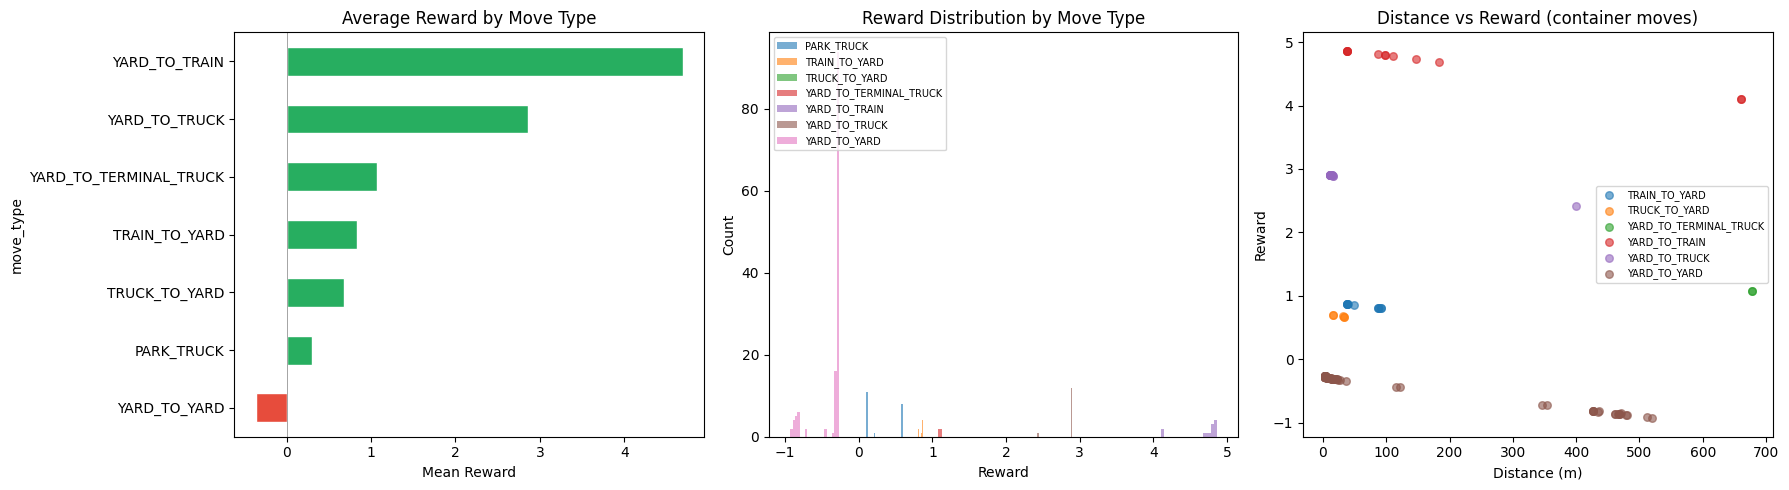

In [7]:
# ================================================================
# Reward distribution analysis
# ================================================================

# Collect all moves into a flat DataFrame
all_moves = []
for sid, r in all_logs.items():
    for m in r["moves"]:
        all_moves.append({
            "scenario": f"S{sid}",
            "move_type": m["move_type"],
            "reward": m["reward"],
            "distance_m": m["distance_m"],
            "time_s": m["time_s"],
        })

df_moves = pd.DataFrame(all_moves)
print(f"Total moves across all scenarios: {len(df_moves)}")
print()
print(df_moves.groupby("move_type").agg(
    count=("reward", "count"),
    mean_reward=("reward", "mean"),
    min_reward=("reward", "min"),
    max_reward=("reward", "max"),
    mean_dist=("distance_m", "mean"),
    mean_time=("time_s", "mean"),
).round(4).to_string())

# ---- Bar chart: average reward per move type ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Average reward by move type
ax = axes[0]
grouped = df_moves.groupby("move_type")["reward"].mean().sort_values()
colors = ["#e74c3c" if v < 0 else "#27ae60" for v in grouped.values]
grouped.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_xlabel("Mean Reward")
ax.set_title("Average Reward by Move Type")
ax.axvline(0, color="gray", lw=0.5)

# 2) Reward histogram by move type
ax = axes[1]
move_types = df_moves["move_type"].unique()
for mt in sorted(move_types):
    subset = df_moves[df_moves["move_type"] == mt]["reward"].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.6, label=mt)
ax.set_xlabel("Reward")
ax.set_ylabel("Count")
ax.set_title("Reward Distribution by Move Type")
ax.legend(fontsize=7, loc="upper left")

# 3) Distance vs reward (container moves only)
ax = axes[2]
container_moves = df_moves[df_moves["distance_m"] > 0].copy()
for mt in sorted(container_moves["move_type"].unique()):
    subset = container_moves[container_moves["move_type"] == mt]
    ax.scatter(subset["distance_m"], subset["reward"], alpha=0.6, label=mt, s=30)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Reward")
ax.set_title("Distance vs Reward (container moves)")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [8]:
# ================================================================
# GPU cleanup
# ================================================================
import gc

agent.q_net.cpu()
agent.target_net.cpu()
agent.replay = None
del agent
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated, "
          f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")

GPU: 11 MB allocated, 26 MB reserved
